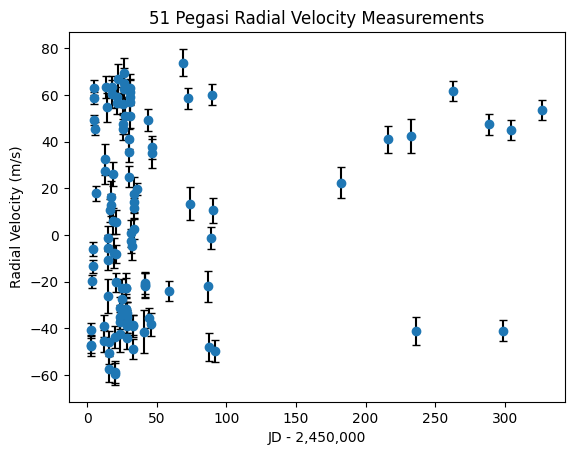

In [10]:
from numpy import*
from matplotlib.pyplot import*

# Load the uploaded data file
data = loadtxt("RV_51Pegasi_Data.txt", skiprows=1)
jd = data[:,0]
rv = data[:,1]
err = data[:,2]

# Plot raw data
errorbar(jd, rv, yerr=err, fmt='o', ecolor='black', capsize=3)
xlabel("JD - 2,450,000")
ylabel("Radial Velocity (m/s)")
title("51 Pegasi Radial Velocity Measurements")
show()


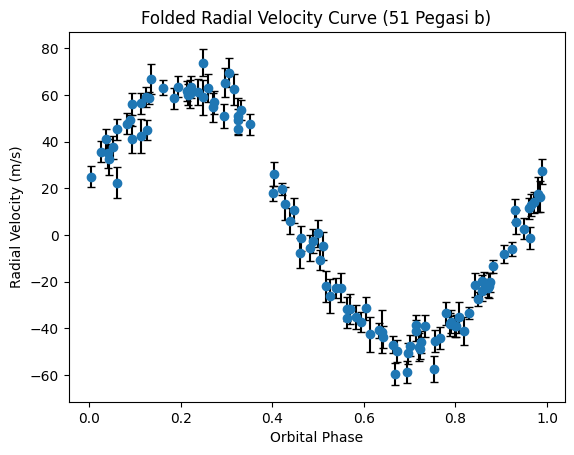

In [11]:
# Fold data using best period
phase = (jd % best_period) / best_period

errorbar(phase, rv, yerr=err, fmt='o', ecolor='black', capsize=3)
xlabel("Orbital Phase")
ylabel("Radial Velocity (m/s)")
title("Folded Radial Velocity Curve (51 Pegasi b)")
show()


In [12]:
from scipy.optimize import curve_fit
from numpy import*

def rv_model(jd, K, e, P, omega_deg, gamma):
    omega = radians(omega_deg)
    M = 2*pi * (jd % P) / P  # mean anomaly
    theta = M + 2*e*sin(M)   # approx true anomaly
    return gamma + K*(cos(theta + omega) + e*cos(omega))

# Fit model (fix omega = 160°)
popt, pcov = curve_fit(lambda jd,K,e,P,gamma: rv_model(jd,K,e,P,160,gamma),
                       jd, rv, sigma=err, p0=[60,0.01,best_period,0])

K_fit, e_fit, P_fit, gamma_fit = popt
print(f"Semi-amplitude K = {K_fit:.2f} m/s")
print(f"Eccentricity e = {e_fit:.3f}")
print(f"Period P = {P_fit:.3f} days")


Semi-amplitude K = -42.64 m/s
Eccentricity e = 0.088
Period P = 4.248 days


In [6]:
import astropy.constants as const
import astropy.units as u

M_star = 1.11 * const.M_sun
P = P_fit * u.day
K = K_fit * (u.m/u.s)
e = e_fit

# Planet mass (m_p sin i)
mp_sini = (K * (M_star**(2/3)) * (P**(1/3)) * (1-e**2)**0.5) / ((2*np.pi*const.G)**(1/3))
mp_sini = mp_sini.to(u.M_jup)
print(f"m_p sin(i) = {mp_sini:.3f}")

# Semi-major axis
a = ((const.G*(M_star))*(P**2)/(4*np.pi**2))**(1/3)
a = a.to(u.AU)
print(f"Semi-major axis a = {a:.3f}")


m_p sin(i) = -0.363 jupiterMass
Semi-major axis a = 0.053 AU


Best-fit orbital period (under 1000 days): 4.22714928292047 days


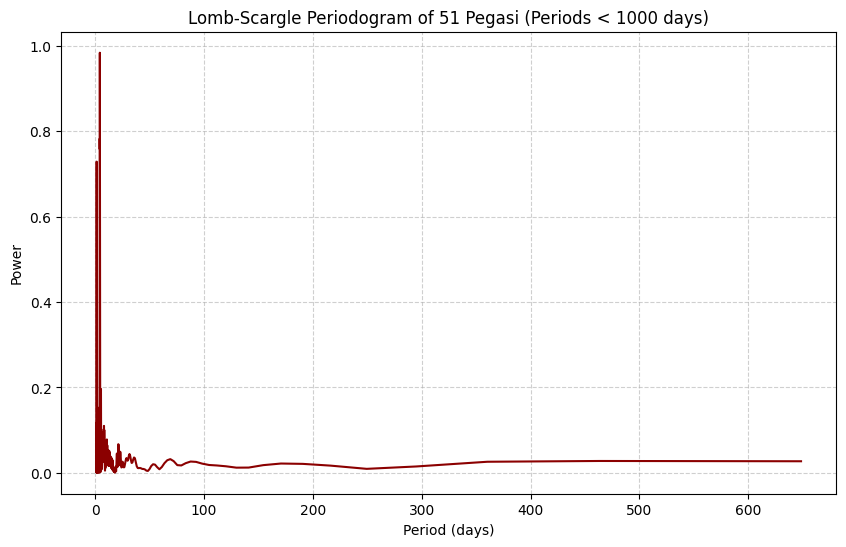

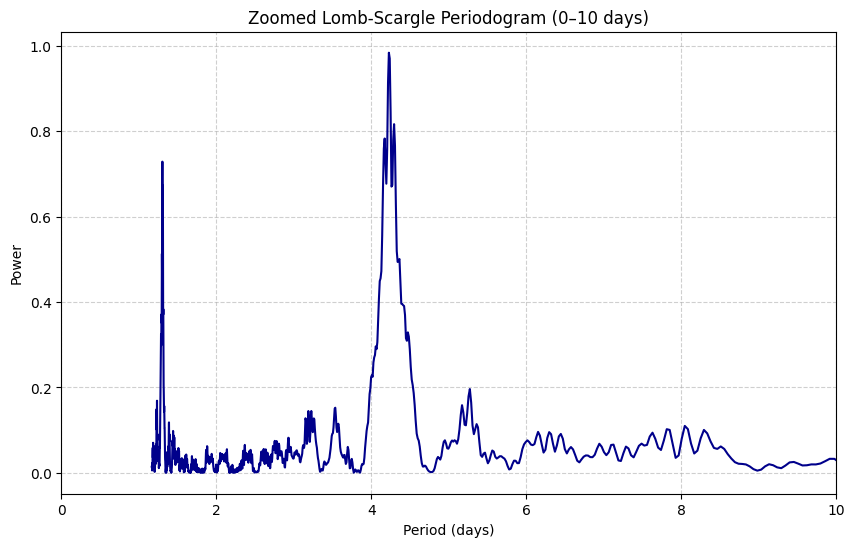

In [14]:
from astropy.timeseries import LombScargle
from numpy import*
from matplotlib.pyplot import*

# Compute Lomb-Scargle periodogram
frequency, power = LombScargle(jd, rv, err).autopower()

# Convert frequency to period (days)
periods = 1 / frequency

# Filter: only keep periods < 1000 days
mask = periods < 1000
periods = periods[mask]
power = power[mask]

# Best period estimate within this range
best_period = periods[argmax(power)]
print("Best-fit orbital period (under 1000 days):", best_period, "days")

# Plot full periodogram (up to 1000 days)
figure(figsize=(10,6))
plot(periods, power, color='darkred')
xlabel("Period (days)")
ylabel("Power")
title("Lomb-Scargle Periodogram of 51 Pegasi (Periods < 1000 days)")
grid(True, linestyle='--', alpha=0.6)
show()

# Zoomed-in plot (0–10 days)
figure(figsize=(10,6))
plot(periods, power, color='darkblue')
xlabel("Period (days)")
ylabel("Power")
title("Zoomed Lomb-Scargle Periodogram (0–10 days)")
xlim(0,10)
grid(True, linestyle='--', alpha=0.6)
show()
